In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [46]:
RANDOM_STATE = 777

In [47]:
df = pd.read_csv(
    filepath_or_buffer='car_price_dataset.csv'
)

In [48]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   str    
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   str    
 5   Transmission  2000 non-null   str    
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), str(3)
memory usage: 172.0 KB


In [50]:
df = df.rename(columns={"Mileage": "mileage_km"})

In [51]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,mileage_km,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [52]:
def standardize_columns_names(df: pd.DataFrame) -> pd.DataFrame:
    df_columns = df.columns
    mapper = {column: column.lower().replace(" ", "_") for column in df_columns}
    df = df.rename(columns=mapper)
    return df

df = standardize_columns_names(df=df)

In [53]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [54]:
categorical_columns = df.select_dtypes(include=["str"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

In [55]:
for column in categorical_columns:
    df[column] = (
        df[column]
        .str.lower()
        .str.replace(" ", "_")
    )

df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35


### Detecting Anomalities with Isolation Forest

In [56]:
isolation_forest = IsolationForest(contamination=0.1, random_state=777)
isolation_forest.fit(df[numerical_columns])

df["anomaly"] = isolation_forest.predict(df[numerical_columns])

In [57]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price,anomaly
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25,-1
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60,1
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40,1
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70,-1
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35,1


In [58]:
df

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price,anomaly
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25,-1
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60,1
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40,1
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70,-1
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,hyundai,2023,4.5,diesel,manual,155033,2,3,310,61734.35,-1
1996,1997,toyota,2023,1.4,petrol,manual,25044,2,4,271,48467.80,-1
1997,1998,hyundai,2022,4.1,diesel,manual,104372,4,3,191,55714.40,1
1998,1999,bmw,2020,4.4,diesel,automatic,158047,4,1,186,53222.65,1


### Detecting Duplicates

In [59]:
df.duplicated().sum()

np.int64(0)

### Label Encoding

In [60]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_columns))

df = pd.concat([df, encoded_df], axis=1)

In [61]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,...,brand_honda,brand_hyundai,brand_tesla,brand_toyota,fuel_type_diesel,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,transmission_automatic,transmission_manual
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_id                  2000 non-null   int64  
 1   brand                   2000 non-null   str    
 2   model_year              2000 non-null   int64  
 3   engine_size             2000 non-null   float64
 4   fuel_type               2000 non-null   str    
 5   transmission            2000 non-null   str    
 6   mileage_km              2000 non-null   int64  
 7   doors                   2000 non-null   int64  
 8   owner_count             2000 non-null   int64  
 9   horsepower              2000 non-null   int64  
 10  price                   2000 non-null   float64
 11  anomaly                 2000 non-null   int64  
 12  brand_bmw               2000 non-null   float64
 13  brand_ford              2000 non-null   float64
 14  brand_honda             2000 non-null   float64
 15

In [63]:
df = df.drop(columns=categorical_columns)
df = df.drop(columns="anomaly")

In [64]:
df.head()

,car_id,model_year,engine_size,mileage_km,doors,owner_count,horsepower,price,brand_bmw,brand_ford,brand_honda,brand_hyundai,brand_tesla,brand_toyota,fuel_type_diesel,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,transmission_automatic,transmission_manual
0,1,2023,1.2,180635,4,3,82,34309.25,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,2018,3.2,35628,2,4,259,55153.60,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3,2008,2.2,74672,3,2,333,41894.40,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,2017,2.2,51246,4,4,381,54046.70,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,5,2012,2.4,147233,3,4,290,38010.35,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Correlation

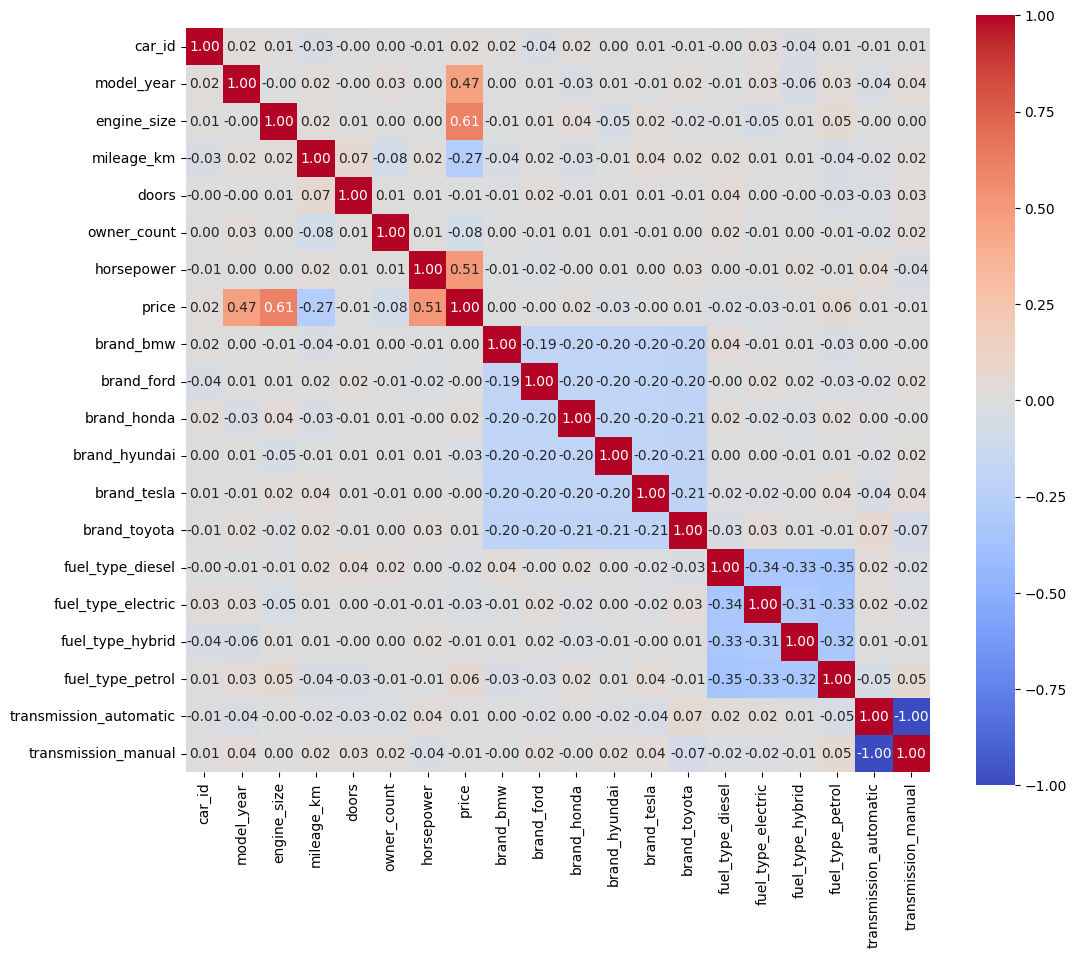

In [66]:
corr = df.corr(
    method="pearson",
    min_periods=1,
    numeric_only=False
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.show()

### Model Building

#### 1. Polynomial Regression

In [69]:
X = df.drop(columns="price")
y = df["price"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [71]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [72]:
polynomial_regression = LinearRegression()
polynomial_regression.fit(X_train_poly_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
y_pred = polynomial_regression.predict(X_test_poly_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1479.2264863339217
MSE: 3033963.4926706194
rMSE: 1741.8276300112532
R2: 0.9632332219989482
